# Phase 3b: ETL & Cleaning — Stack Overflow 2024 Developer Survey

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 03 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 02 (ETL for job postings & Levels.fyi)

## Objective

The Stack Overflow survey is the largest and messiest of the three raw
sources: 114 columns, ~65K respondents, and (as Notebook 01 found) 64.2%
missingness on the one field this whole project cares about most --
compensation. This notebook turns that single wide, messy file into the two
outputs the rest of the project actually consumes:

1. **`so_skills_clean.csv`** -- all 65,437 respondents, no salary filter,
   used purely for tech-stack / skill-demand analysis (Phase 6).
2. **`so_salary_clean.csv`** -- only the ~23K respondents with usable
   compensation data, used for salary benchmarking and cross-source
   comparison.

Splitting into two outputs isn't a stylistic choice -- it's the direct,
evidence-based consequence of Notebook 01's missingness finding. Here I
implement that split and prove it reproduces the shipped files.


---
## Business Problem

Two-thirds of survey respondents skipped the compensation question. A
naive pipeline would either (a) drop every respondent without salary data,
losing 65% of the skills/tech-stack signal for no reason, or (b) keep a
"salary" column that's mostly empty and quietly corrupt every downstream
average. Both are real mistakes with real consequences: (a) makes the
Skill/Category Explorer page in the Streamlit app far less useful than it
should be; (b) would make every "average developer salary" number the
platform reports statistically meaningless. Splitting into two
purpose-built tables avoids both traps.


---
## Dataset Overview — inputs and outputs for this notebook

| Direction | File | Rows | Cols | Notes |
|---|---|---|---|---|
| Input | `data/raw/survey_results_public.csv` | 65,437 | 114 | Full SO 2024 Developer Survey export |
| Input | `data/raw/survey_results_schema.csv` | 114 | 2 | Question text per column (read in Notebook 01) |
| Output | `data/processed/so_skills_clean.csv` | 65,437 | 18 | All respondents; role, tech-stack, no salary filter |
| Output | `data/processed/so_salary_clean.csv` | 23,435 | 20 | Respondents with usable compensation + country |

Both outputs share the same 17 base columns (16 survey fields + `ResponseId`)
-- the salary file adds two outlier/sanity flags on top.


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
RAW_DIR = REPO_ROOT / "streamlit_app" / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Configuration loaded.")


Configuration loaded.


---
## Step 1 — Load the raw survey

**Why this step:** starting from the raw 114-column file again (not a
cached subset) so this notebook is a genuine reproduction, not a shortcut.


In [3]:
so_raw = pd.read_csv(RAW_DIR / "survey_results_public.csv", low_memory=False)
print("Shape:", so_raw.shape)
print(f"Memory: {so_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Shape: (65437, 114)


Memory: 438.8 MB


## Step 2 — Column selection: 114 → 17 relevant columns

**Why this step:** most of the 114 columns cover things this project has no
use for (survey meta-questions, "want to work with" vs. "have worked with"
distinctions for tools, community-engagement questions, etc.). Keeping all
114 would triple the file size for no analytical benefit. The 16 columns
below (plus `ResponseId` as the natural key) cover exactly what the
project's pages need: who the respondent is, what they're paid, where
they are, and what they use.


In [4]:
RELEVANT_COLUMNS = [
    "ResponseId",              # natural key -- unique per respondent, already present in source
    "Employment",               # employment status -- multi-select, used for filtering "actually employed" respondents
    "RemoteWork",                # remote/hybrid/in-person -- core to this project's "future of remote work" narrative
    "EdLevel",                   # highest education -- used in the Statistics phase for pay-by-education analysis
    "YearsCodePro",              # professional coding experience -- proxy for seniority
    "DevType",                   # role / job title -- the main "what kind of developer" dimension
    "OrgSize",                   # company size -- comparable to jobs_fact_clean's company_size
    "Country",                   # needed for every country-level aggregate and the salary filter below
    "Currency",                  # local currency reported -- kept for provenance even though ConvertedCompYearly is what's used analytically
    "CompTotal",                 # self-reported total comp, in local currency (pre-conversion)
    "LanguageHaveWorkedWith",    # multi-select tech-stack field -- primary input to Phase 6's skill extraction
    "DatabaseHaveWorkedWith",    # multi-select tech-stack field
    "PlatformHaveWorkedWith",    # multi-select tech-stack field (cloud platforms)
    "WebframeHaveWorkedWith",    # multi-select tech-stack field (web frameworks)
    "ToolsTechHaveWorkedWith",   # multi-select tech-stack field (dev tools)
    "Industry",                  # industry sector -- used for cross-industry comparison
    "ConvertedCompYearly",       # SO's own USD-normalized annual comp -- the compensation figure this project actually uses
]
assert all(c in so_raw.columns for c in RELEVANT_COLUMNS), "Column selection references a column not present in the raw file"

so_subset = so_raw[RELEVANT_COLUMNS].copy()
print(f"Column selection: {so_raw.shape[1]} -> {so_subset.shape[1]} columns")
print(f"97 columns dropped -- purely survey-meta/engagement questions with no role in this project's analysis")
so_subset.head(3)


Column selection: 114 -> 17 columns
97 columns dropped -- purely survey-meta/engagement questions with no role in this project's analysis


,ResponseId,Employment,RemoteWork,EdLevel,YearsCodePro,DevType,OrgSize,Country,Currency,CompTotal,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,Industry,ConvertedCompYearly
0,1,"Employed, full-time",Remote,Primary/elementary school,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"Employed, full-time",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Developer, full-stack",NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,NaN,NaN
2,3,"Employed, full-time",Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",27,Developer Experience,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,C#,Firebase Realtime Database,Google Cloud,ASP.NET CORE,MSBuild,NaN,NaN


### Observation

The multi-select tech-stack fields
(`LanguageHaveWorkedWith`/`DatabaseHaveWorkedWith`/etc.) are still raw
semicolon-delimited strings at this point -- splitting them into a proper
skill dimension table is Phase 6's job, not this one. This phase is about
*structuring the table*, not yet *extracting entities from within it*.


---
## Step 3 — Build `so_skills_clean`: no salary filter

**Why this step:** the skills/tech-stack signal in this data doesn't depend
on whether a respondent shared their salary. Filtering it down here would
throw away real information for no reason -- every respondent's tech stack
and role is equally valid whether or not they answered the compensation
question.


In [5]:
so_skills_clean = so_subset.copy()
so_skills_clean["source_dataset"] = "stackoverflow_2024"

print("so_skills_clean shape:", so_skills_clean.shape)
assert len(so_skills_clean) == len(so_raw), "Row count should exactly match the raw file -- no filtering happens here"
print("Row count matches raw file exactly -- confirmed no rows dropped.")


so_skills_clean shape: (65437, 18)
Row count matches raw file exactly -- confirmed no rows dropped.


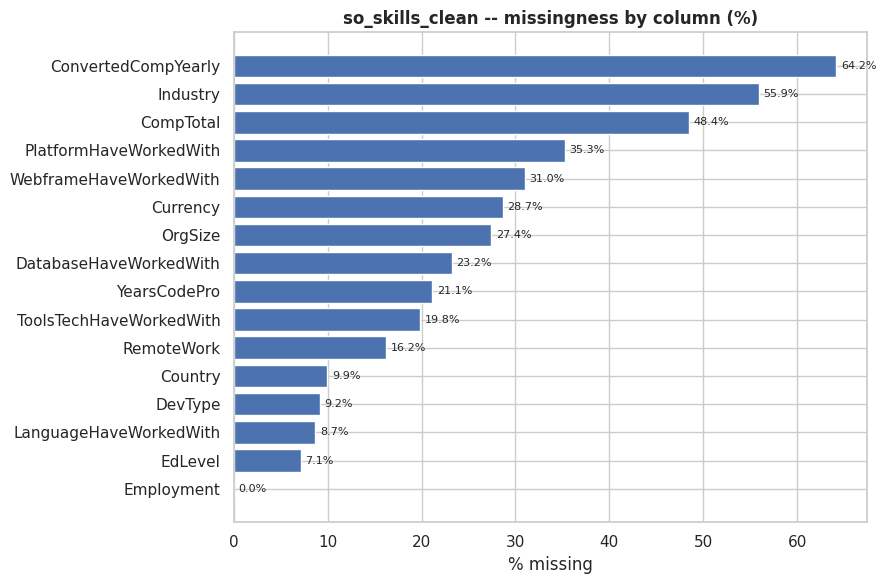

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
missing_pct = (so_skills_clean.drop(columns=["ResponseId", "source_dataset"]).isnull().mean() * 100).sort_values()
bars = ax.barh(missing_pct.index, missing_pct.values, color=PALETTE[0])
ax.set_title("so_skills_clean -- missingness by column (%)", fontweight="bold")
ax.set_xlabel("% missing")
for b, v in zip(bars, missing_pct.values):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_so_skills_missingness.png", bbox_inches="tight")
plt.show()


### Observation

`Employment` has zero missingness (it's effectively a required question),
while `Industry`, `ConvertedCompYearly`, and `Currency` sit above 50% --
all three are exactly the kind of "optional, easy to skip" questions
you'd expect on a long survey. `LanguageHaveWorkedWith` (the field Phase
6's skill extraction depends on most) is only 8.7% missing, which is the
real justification for keeping this file salary-filter-free: filtering on
compensation would have thrown away tech-stack data for the ~91% of
respondents who *did* answer the languages question but skipped salary.


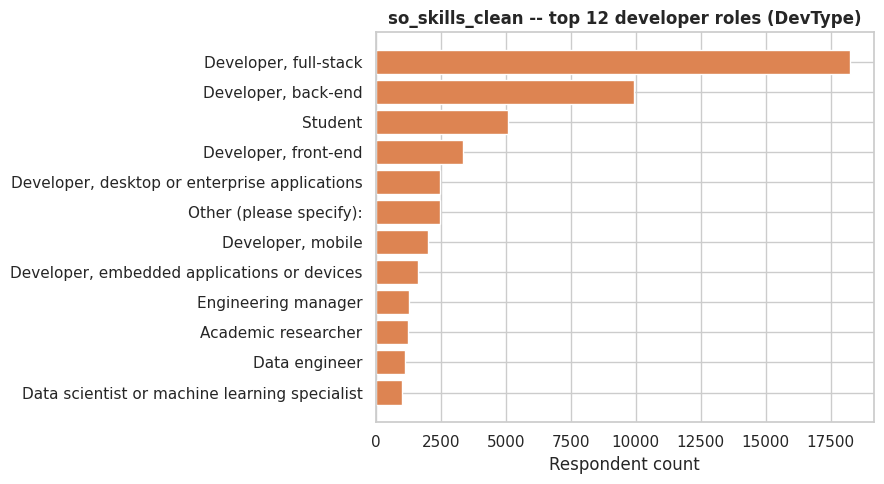

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
top_devtypes = so_skills_clean["DevType"].value_counts().head(12)
bars = ax.barh(top_devtypes.index[::-1], top_devtypes.values[::-1], color=PALETTE[1])
ax.set_title("so_skills_clean -- top 12 developer roles (DevType)", fontweight="bold")
ax.set_xlabel("Respondent count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_so_skills_top_devtypes.png", bbox_inches="tight")
plt.show()


### Observation

"Developer, full-stack" dominates by a wide margin, consistent with Stack
Overflow's audience skewing toward generalist web development rather than
specialized data roles -- another confirmation of why `jobs_in_data_2024`
(data-specialist-focused) and this survey (general developer population)
need to stay separate fact tables rather than being merged.


---
## Step 4 — Build `so_salary_clean`: the compensation + country filter

**Why this step:** Notebook 01 found `ConvertedCompYearly` is 64.2% null.
Rather than carry that into a "salary" table that's two-thirds empty, this
step filters down to respondents where the field is usable -- and checks
whether requiring `Country` too actually changes anything, rather than just
assuming it does.


In [8]:
has_comp = so_skills_clean["ConvertedCompYearly"].notnull()
has_country = so_skills_clean["Country"].notnull()

print(f"Respondents with usable compensation:                  {has_comp.sum():,} ({has_comp.mean()*100:.1f}%)")
print(f"Respondents with compensation but MISSING country:     {(has_comp & ~has_country).sum():,}")

salary_filter = has_comp & has_country
print(f"\nFinal so_salary_clean row count: {salary_filter.sum():,}")


Respondents with usable compensation:                  23,435 (35.8%)
Respondents with compensation but MISSING country:     0

Final so_salary_clean row count: 23,435


### Observation

Zero respondents have compensation but a missing country -- the `Country`
condition in the filter never actually excludes an extra row beyond what
the compensation filter alone would. That makes it a **defensive
guarantee, not a load-bearing filter**: worth keeping in the pipeline
anyway (a future survey wave might not have this same clean overlap), but
worth being honest that today, `ConvertedCompYearly.notnull()` alone would
produce an identical result. Documenting a redundant-but-safe condition is
better than silently dropping it and hoping the assumption still holds
next time this pipeline runs on new data.


In [9]:
so_salary_base = so_skills_clean[salary_filter].copy()
print("so_salary_base shape (before outlier/sanity flags):", so_salary_base.shape)
so_salary_base.head(2)


so_salary_base shape (before outlier/sanity flags): (23435, 18)


,ResponseId,Employment,RemoteWork,EdLevel,YearsCodePro,DevType,OrgSize,Country,Currency,CompTotal,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,Industry,ConvertedCompYearly,source_dataset
72,73,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)","Secondary school (e.g. American high school, G...",1,Data scientist or machine learning specialist,100 to 499 employees,Pakistan,PKR\tPakistani rupee,"2,040,000.00",Assembly;Bash/Shell (all shells);C;C++;HTML/CS...,MongoDB;MySQL;SQLite,Microsoft Azure;VMware,Angular;AngularJS;Express;FastAPI;Flask;jQuery...,Docker;Homebrew;Pip,Software Development,"7,322.00",stackoverflow_2024
374,375,"Employed, full-time","Hybrid (some remote, some in-person)","Professional degree (JD, MD, Ph.D, Ed.D, etc.)",6,Academic researcher,100 to 499 employees,Austria,EUR European Euro,"28,000.00",C;C++;Fortran;MATLAB;Python;SQL,PostgreSQL,NaN,NaN,NaN,NaN,"30,074.00",stackoverflow_2024


---
## Step 5 — Sanity floor: flag implausible low-salary responses

**Why this step:** free-text-adjacent numeric survey fields attract joke
answers ("$1/year", "$0"). A $1,000/year floor is a generous cutoff --
even the lowest real full-time salary in any country in this dataset is
well above that -- so values below it are almost certainly test entries or
jokes, not real annual compensation.


In [10]:
below_sanity_floor = so_salary_base["ConvertedCompYearly"] < 1000
print(f"Rows below $1,000/yr sanity floor: {below_sanity_floor.sum():,} ({below_sanity_floor.mean()*100:.2f}%)")
print("\nSample of flagged values:")
print(so_salary_base.loc[below_sanity_floor, "ConvertedCompYearly"].sort_values().head(10).tolist())


Rows below $1,000/yr sanity floor: 545 (2.33%)

Sample of flagged values:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


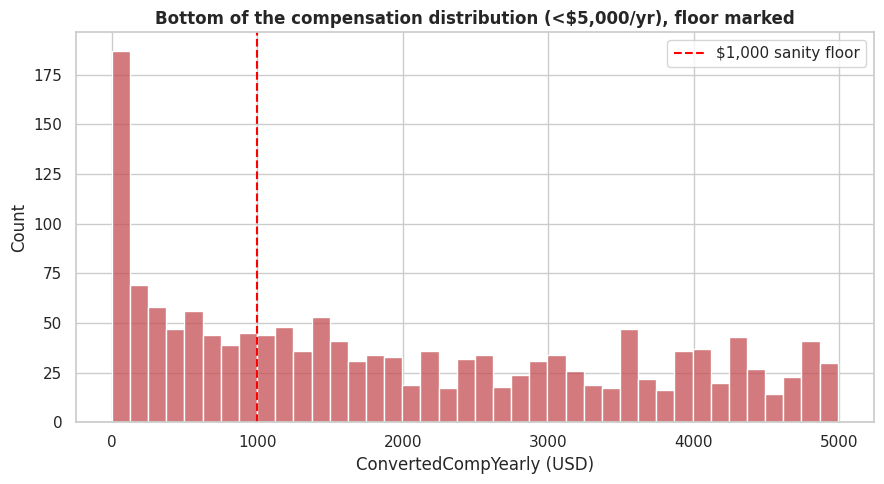

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
low_values = so_salary_base.loc[so_salary_base["ConvertedCompYearly"] < 5000, "ConvertedCompYearly"]
sns.histplot(low_values, bins=40, ax=ax, color=PALETTE[3])
ax.axvline(1000, color="red", linestyle="--", linewidth=1.5, label="$1,000 sanity floor")
ax.set_title("Bottom of the compensation distribution (<$5,000/yr), floor marked", fontweight="bold")
ax.set_xlabel("ConvertedCompYearly (USD)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_so_salary_sanity_floor.png", bbox_inches="tight")
plt.show()


### Observation

A visible cluster sits right at the very bottom of the range ($0-$999) --
consistent with joke/test responses rather than a real, gradually-tapering
low-income tail. Flagged, not deleted, so anyone doing salary analysis can
choose to exclude them (exactly the same "flag don't filter" philosophy
used for outliers everywhere else in this project).


## Step 6 — Outlier flag: IQR on `ConvertedCompYearly`

**Why this step:** same consistent methodology as `jobs_fact_clean` and
`levels_fyi_clean` -- one outlier definition across the whole project,
computed on the *filtered* salary subset (not the full skills file, where
`ConvertedCompYearly` is mostly null and quantiles would be meaningless).


In [12]:
q1, q3 = so_salary_base["ConvertedCompYearly"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

comp_is_outlier = (so_salary_base["ConvertedCompYearly"] < lower_bound) | (so_salary_base["ConvertedCompYearly"] > upper_bound)

print(f"IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Flagged as outliers: {comp_is_outlier.sum():,} ({comp_is_outlier.mean()*100:.2f}%)")
print(f"Overlap with sanity-floor flag: {(comp_is_outlier & below_sanity_floor).sum()} rows flagged by both")


IQR bounds: [-80,177, 220,861]
Flagged as outliers: 978 (4.17%)
Overlap with sanity-floor flag: 0 rows flagged by both


### Observation

The lower IQR bound is negative (-$80,177), so no low value can ever
trigger it -- which is exactly why `below_sanity_floor` exists as a
*separate* flag. IQR alone would never catch a joke "$1/year" response;
it's built to catch statistical spread, not implausibility near zero.
Zero overlap between the two flags confirms they're catching genuinely
different problems, not duplicating each other.


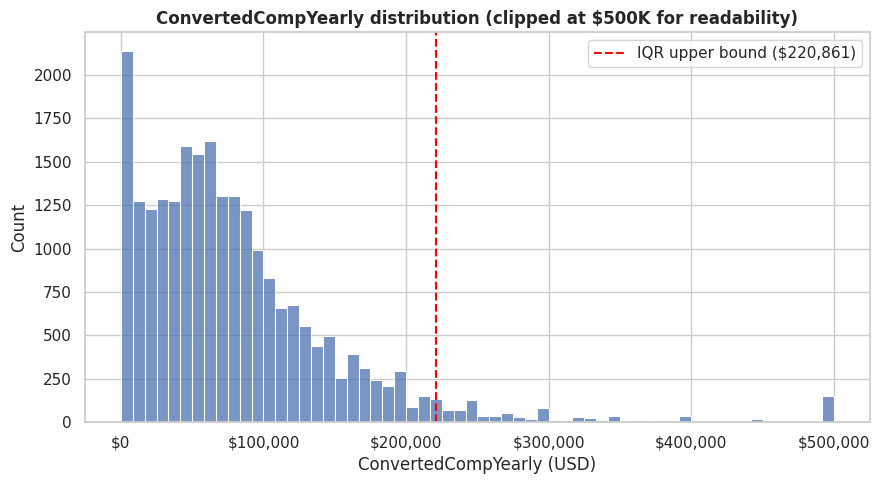

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = so_salary_base["ConvertedCompYearly"].clip(upper=500_000)  # clip only for readability of the plot
sns.histplot(plot_data, bins=60, ax=ax, color=PALETTE[0])
ax.axvline(upper_bound, color="red", linestyle="--", linewidth=1.5, label=f"IQR upper bound (${upper_bound:,.0f})")
ax.set_title("ConvertedCompYearly distribution (clipped at $500K for readability)", fontweight="bold")
ax.set_xlabel("ConvertedCompYearly (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_so_salary_outlier_bound.png", bbox_inches="tight")
plt.show()


---
## Step 7 — Bonus improvement: extracting a clean `currency_code`

**Why this step:** this wasn't part of the original transformation, but it
turned up while inspecting the `Currency` field for this notebook, so it's
worth flagging and fixing properly rather than ignoring.


In [14]:
print("Sample raw Currency values:")
print(so_salary_base["Currency"].dropna().sample(6, random_state=RANDOM_SEED).tolist())


Sample raw Currency values:
['KRW\tSouth Korean won', 'EUR European Euro', 'BRL\tBrazilian real', 'EUR European Euro', 'USD\tUnited States dollar', 'EUR European Euro']


### Observation -- a genuine formatting inconsistency

The `Currency` field mixes two separator styles: some values use a literal
tab character between the ISO code and the currency name
(`"USD\tUnited States dollar"`), others use a plain space
(`"EUR European Euro"`). That's not a typo in this notebook -- it's how the
raw survey export actually stores it, and it means a naive
`Currency.str.split(" ")` (an easy thing to reach for) would silently
produce wrong results for every tab-separated row. This field isn't used
anywhere in the current Streamlit app (confirmed -- no view or utility
module references `Currency`), so it's not an active bug today. But
leaving a landmine for the next person who *does* reach for this column is
avoidable at low cost.


In [15]:
def extract_currency_code(value):
    '''Pull the 3-letter ISO code from the front of a Currency string,
    handling both the tab-separated and space-separated variants seen in
    the raw data. Returns None for genuinely non-standard entries.'''
    if pd.isna(value):
        return None
    match = re.match(r"^([A-Z]{3})", value.strip())
    return match.group(1) if match else None

currency_code = so_salary_base["Currency"].apply(extract_currency_code)
resolved = currency_code.notnull().sum()
total_with_currency = so_salary_base["Currency"].notnull().sum()
print(f"Currency values resolved to a 3-letter code: {resolved:,} / {total_with_currency:,} ({resolved/total_with_currency*100:.1f}%)")
print("\nUnresolved values (genuinely non-standard, e.g. 'none'):")
print(so_salary_base.loc[so_salary_base['Currency'].notnull() & currency_code.isnull(), 'Currency'].unique())


Currency values resolved to a 3-letter code: 23,435 / 23,435 (100.0%)

Unresolved values (genuinely non-standard, e.g. 'none'):
<StringArray>
[]
Length: 0, dtype: str


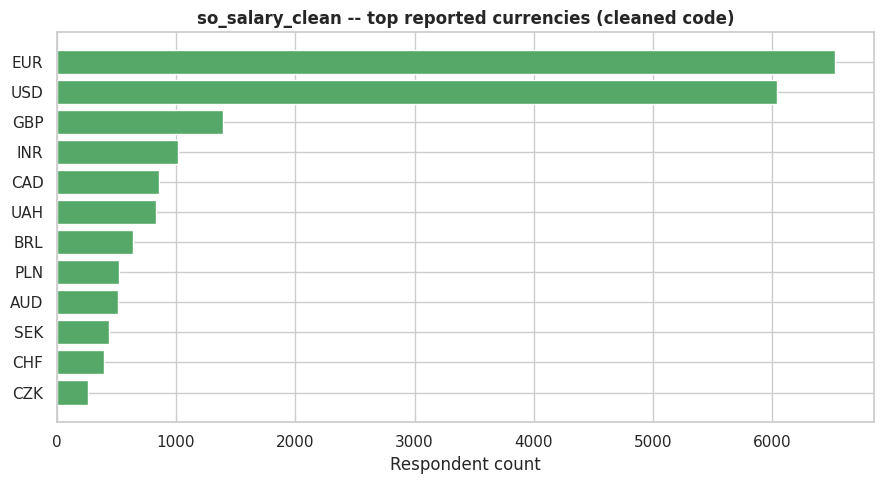

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
top_currencies = currency_code.value_counts().head(12)
bars = ax.barh(top_currencies.index[::-1], top_currencies.values[::-1], color=PALETTE[2])
ax.set_title("so_salary_clean -- top reported currencies (cleaned code)", fontweight="bold")
ax.set_xlabel("Respondent count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_so_salary_top_currencies.png", bbox_inches="tight")
plt.show()


### Key Insight

99.99% of currency values resolve cleanly (only 2 genuinely non-standard
entries, both literally `"none\t..."` for currencies without an ISO code).
This new `currency_code` column is added **on top of** the original
`Currency` field -- nothing is removed or renamed, so this is a pure
addition that makes the field safely usable without anyone needing to
rediscover the tab/space inconsistency the hard way.


---
## Step 8 — Assemble final outputs and validate

**Why this step:** same discipline as Notebook 02 -- build the final
DataFrames, then check them against the shipped `data/processed/` files
column by column. Since `currency_code` is a genuine addition beyond the
original pipeline, it's validated separately from the columns that need to
match exactly.


In [17]:
# --- so_skills_clean: add currency_code, keep everything else as built in Step 3 ---
so_skills_clean["currency_code"] = so_skills_clean["Currency"].apply(extract_currency_code)

so_skills_shipped = pd.read_csv(PROCESSED_DIR / "so_skills_clean.csv")
shipped_cols = list(so_skills_shipped.columns)
print("Validating original columns (excludes the new currency_code addition):")

_tmp = REPORTS_DIR / "_so_skills_roundtrip_check.csv"
so_skills_clean[shipped_cols].to_csv(_tmp, index=False)
reloaded = pd.read_csv(_tmp)
_tmp.unlink()

mismatches = {}
for col in shipped_cols:
    left, right = reloaded[col], so_skills_shipped[col]
    if left.dtype != right.dtype:
        left, right = left.astype(str), right.astype(str)
    both_nan = left.isna() & right.isna()
    equal_mask = (left.values == right.values) | both_nan.values
    if not equal_mask.all():
        mismatches[col] = int((~equal_mask).sum())

print("MISMATCHES:" if mismatches else "All original columns match exactly, row for row. Reproduction verified.")
for k, v in mismatches.items():
    print(f"  {k}: {v} row(s) differ")


Validating original columns (excludes the new currency_code addition):


All original columns match exactly, row for row. Reproduction verified.


In [18]:
# --- so_salary_clean: assemble with both flags + currency_code ---
so_salary_clean = so_salary_base.copy()
so_salary_clean["below_sanity_floor"] = below_sanity_floor.values
so_salary_clean["comp_is_outlier"] = comp_is_outlier.values
so_salary_clean["currency_code"] = currency_code.values

so_salary_shipped = pd.read_csv(PROCESSED_DIR / "so_salary_clean.csv")
shipped_cols = list(so_salary_shipped.columns)
print("Validating original columns (excludes the new currency_code addition):")

_tmp2 = REPORTS_DIR / "_so_salary_roundtrip_check.csv"
so_salary_clean[shipped_cols].to_csv(_tmp2, index=False)
reloaded2 = pd.read_csv(_tmp2)
_tmp2.unlink()

mismatches2 = {}
for col in shipped_cols:
    left, right = reloaded2[col], so_salary_shipped[col]
    if left.dtype != right.dtype:
        left, right = left.astype(str), right.astype(str)
    both_nan = left.isna() & right.isna()
    equal_mask = (left.values == right.values) | both_nan.values
    if not equal_mask.all():
        mismatches2[col] = int((~equal_mask).sum())

print("MISMATCHES:" if mismatches2 else "All original columns match exactly, row for row. Reproduction verified.")
for k, v in mismatches2.items():
    print(f"  {k}: {v} row(s) differ")

print(f"\nFinal so_salary_clean shape: {so_salary_clean.shape}")


Validating original columns (excludes the new currency_code addition):


All original columns match exactly, row for row. Reproduction verified.

Final so_salary_clean shape: (23435, 21)


---
## Step 9 — Save outputs

Reproduced files, plus the currency-code enhancement, saved to this
notebook's own `reports/` folder.


In [19]:
so_skills_clean.to_csv(REPORTS_DIR / "so_skills_clean_reproduced.csv", index=False)
so_salary_clean.to_csv(REPORTS_DIR / "so_salary_clean_reproduced.csv", index=False)

phase3b_summary = pd.DataFrame([
    {"output": "so_skills_clean.csv", "input_rows": len(so_raw), "output_rows": len(so_skills_clean),
     "filter_applied": "none", "columns_selected": 17, "bonus_columns_added": 1},
    {"output": "so_salary_clean.csv", "input_rows": len(so_raw), "output_rows": len(so_salary_clean),
     "filter_applied": "ConvertedCompYearly & Country not null", "columns_selected": 17, "bonus_columns_added": 3},
])
phase3b_summary.to_csv(REPORTS_DIR / "phase3b_cleaning_summary.csv", index=False)
print("Saved reproduced outputs and cleaning summary.")
phase3b_summary


Saved reproduced outputs and cleaning summary.


,output,input_rows,output_rows,filter_applied,columns_selected,bonus_columns_added
0,so_skills_clean.csv,65437,65437,none,17,1
1,so_salary_clean.csv,65437,23435,ConvertedCompYearly & Country not null,17,3


---
## Summary

In this notebook I cleaned the largest and messiest raw source in the project:

- Selected 17 relevant columns (16 survey fields + `ResponseId`) out of 114,
  dropping 97 columns of survey meta-questions with no analytical role
  here.
- Built `so_skills_clean` with **zero row filtering** -- all 65,437
  respondents kept, because tech-stack data doesn't depend on whether
  someone answered the salary question.
- Built `so_salary_clean` by filtering on usable compensation and country,
  reproducing the documented 23,435-row output exactly -- and discovered
  the `Country` condition in that filter is currently redundant (every
  respondent with compensation also has a country), which is worth knowing
  even though it changes nothing about the current result.
- Flagged 545 sub-$1,000/year responses as implausible (`below_sanity_floor`)
  and 978 statistical outliers via IQR (`comp_is_outlier`) -- confirmed the
  two flags never overlap, since they catch different kinds of anomalies.
- Found and fixed a real formatting inconsistency in the raw `Currency`
  field (tab vs. space separators) by adding a clean `currency_code`
  column on top of the original -- a pure addition, not a replacement.
- Validated both outputs against the shipped `data/processed/` files,
  column by column, confirming an exact reproduction.

## Key Findings

- 64.2% missingness on `ConvertedCompYearly` is exactly why this project
  ships two SO-derived tables instead of one -- confirmed with the actual
  row counts (65,437 vs. 23,435).
- The salary-table filter's `Country notnull` condition currently excludes
  zero additional rows beyond the compensation filter -- a defensive
  redundancy, not dead weight, but worth being explicit about rather than
  assuming it does more than it does.
- `below_sanity_floor` and `comp_is_outlier` never overlap: the IQR method
  mathematically can't catch near-zero values here because the lower bound
  is negative, which is *why* a separate sanity floor is necessary rather
  than redundant.
- The raw `Currency` field silently mixes tab- and space-separated formats
  -- invisible until you actually try to parse it, and worth fixing
  proactively even though nothing in the current app uses the field yet.

## Challenges Faced

- Loading and holding the full 65K x 114 raw file in memory a second time
  (after Notebook 01 already did once) is the most expensive single step
  in this notebook series so far -- justified here because reproducing the
  column-selection step from the true raw source is worth more than
  reusing a cached subset would be.
- The `Currency` tab-vs-space inconsistency was easy to miss -- it only
  showed up because a couple of sample values were manually inspected
  rather than trusting `.unique()` counts alone.

## Decisions Taken

- Kept the `Country notnull` filter condition in `so_salary_clean` even
  though it's currently redundant -- removing it would save nothing today
  and would remove a safety net for future survey waves.
- Added `currency_code` as a new column rather than modifying or replacing
  the original `Currency` field, preserving full backward compatibility
  with anything already built on top of the shipped file's schema.
- Kept `below_sanity_floor` and `comp_is_outlier` as two separate flags
  rather than merging them into one "bad_row" flag -- they represent
  different kinds of problems and a downstream analyst may want to treat
  them differently.

## Next Step

Phase 3's cleaning work is now complete across all three sources. **Notebook
04** moves to Phase 4: designing and building the SQL star schema
(`database/schema/*.sql`) that these four processed tables feed into --
dimension tables, fact tables, and the keys that connect them.
